In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.splat as splat
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime
import os

from rubin_sim.splat.plots import bright_filter_colors

from rubin_sim.data import get_baseline
from os.path import basename
import glob


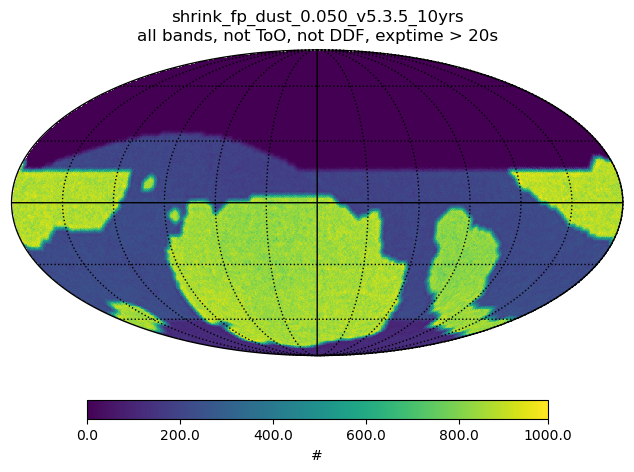

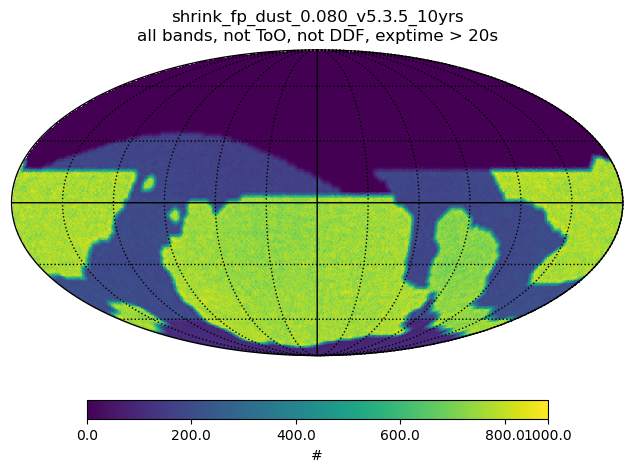

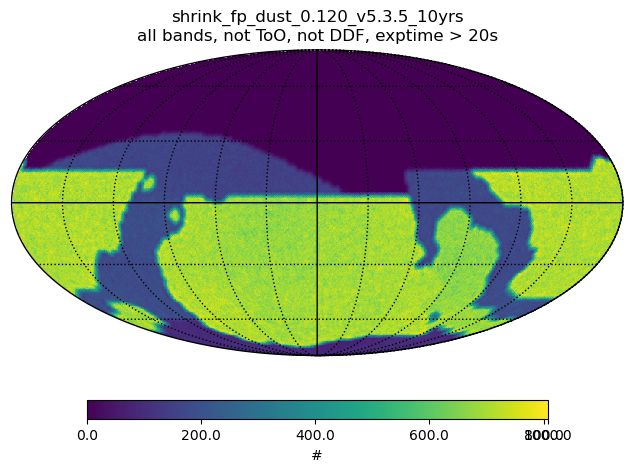

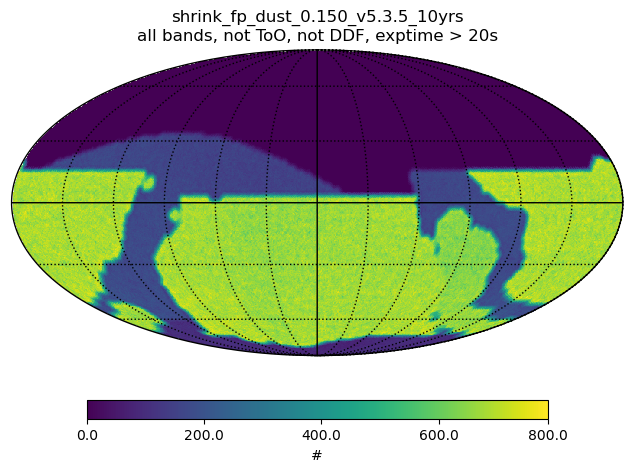

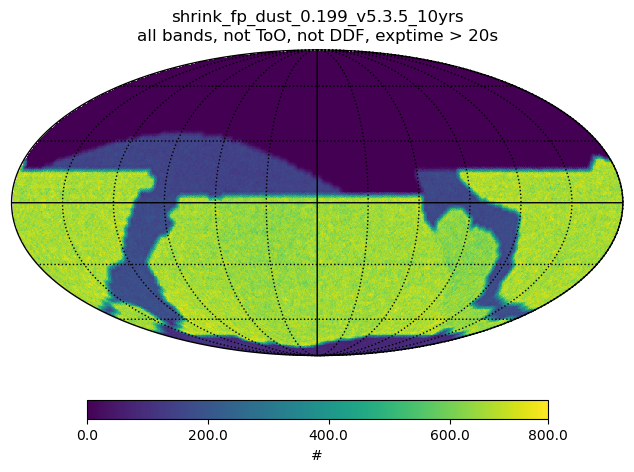

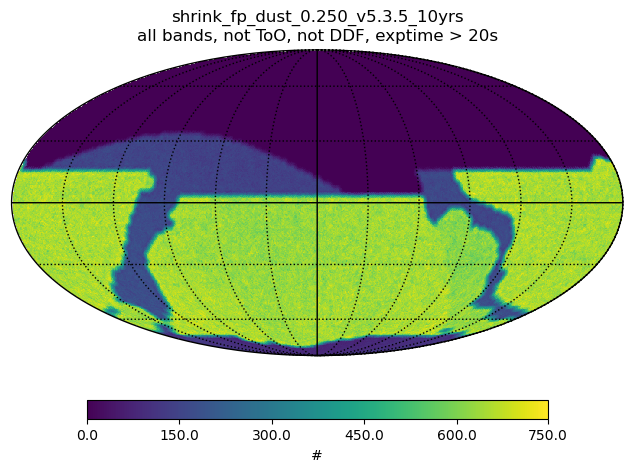

In [2]:
db_files = glob.glob("*10yrs.db")
db_files.sort()
fig_saver = splat.FigSaver(close_figs=False)

stats = []

for db_file in db_files:

    run_name = basename(db_file).replace('.db', '')
    con = sqlite3.connect(db_file)
    df = pd.read_sql('select * from observations;', con)
    con.close()
    # Convert to a numpy array
    visits_array = df.to_records(index=False)

    
    info = {"data_source": run_name}
    info["observations_subset"] = "all bands, not ToO, not DDF, exptime > 20s"
    not_too = np.array(["ToO" not in note for note in visits_array["scheduler_note"]])
    not_ddf = np.array(["DD" not in note for note in visits_array["scheduler_note"]])
    indx = np.where((not_too == True) & (visits_array["visitExposureTime"] >= 20.)
                   & (not_ddf == True))
    sub_data = visits_array[indx]
    metric = splat.CountMetric()
    sl = splat.Slicer(nside=128, missing=0)
    hp_array, info = sl(sub_data, metric, info=info)
    pm = splat.PlotMoll(info=info)
    fig = pm(hp_array)

    nside = hp.npix2nside(hp_array.size)

    wfd_pix = np.where( hp_array > 600)[0]
    area = hp.nside2pixarea(nside, degrees=True)* wfd_pix.size

    stats.append([run_name, np.median(hp_array[wfd_pix]), area])
    

In [5]:
# Note here WFD is low dust, GP, LMC/SMC, Virgo. 
pd.DataFrame(stats, columns=["run name", "Median N in WFD", "Area in WFD (sq deg)"])

,run name,Median N in WFD,Area in WFD (sq deg)
0,shrink_fp_dust_0.050_v5.3.5_10yrs,853.0,13278.464761
1,shrink_fp_dust_0.080_v5.3.5_10yrs,755.0,15961.266898
2,shrink_fp_dust_0.120_v5.3.5_10yrs,698.0,17799.110157
3,shrink_fp_dust_0.150_v5.3.5_10yrs,677.0,18574.407662
4,shrink_fp_dust_0.199_v5.3.5_10yrs,656.0,19202.618956
5,shrink_fp_dust_0.250_v5.3.5_10yrs,644.0,19181.426791
